In [ ]:
# INSTALL REQUIRED PACKAGES
!pip install kagglehub
!pip install tensorflow
!pip install scikit-learn
!pip install matplotlib seaborn
!pip install pillow

In [ ]:
# IMPORTS
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
import kagglehub
import random

# For classical models and ML evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# For deep learning model
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [ ]:
# DOWNLOAD DATASET
path = kagglehub.dataset_download("sartajbhuvaji/brain-tumor-classification-mri")
print("Dataset path:", path)

train_dir = os.path.join(path, "Training")
test_dir  = os.path.join(path, "Testing")

print("Train classes:", os.listdir(train_dir))
print("Test classes:", os.listdir(test_dir))

Using Colab cache for faster access to the 'brain-tumor-classification-mri' dataset.
Dataset path: /kaggle/input/brain-tumor-classification-mri
Train classes: ['no_tumor', 'pituitary_tumor', 'meningioma_tumor', 'glioma_tumor']
Test classes: ['no_tumor', 'pituitary_tumor', 'meningioma_tumor', 'glioma_tumor']


In [ ]:
# LOAD DATA FOR ML MODELS
def load_images_for_ml(folder_path, img_size=(64, 64)):
    X, y = [], [] # X will store image data, y will store numeric labels
    classes = sorted(os.listdir(folder_path))  # Get list of class folders

    # Loop through each class folder
    for label, category in enumerate(classes):
        category_path = os.path.join(folder_path, category)

        # Loop through each image file in the class folder
        for filename in os.listdir(category_path):
            img_path = os.path.join(category_path, filename)
            try:
                img = Image.open(img_path).convert("L")  # Open image and convert to grayscale
                img = img.resize(img_size) # Resize all images to the same size
                X.append(np.array(img).flatten()) # Convert image to array and flatten into 1D vector
                y.append(label) # Store numeric label (0,1,2,3 for the 4 classes)
            except:
                continue # If any image is corrupted, just skip it

    return np.array(X), np.array(y) # Convert lists to NumPy arrays for ML model use


# Load training and testing data for classical ML models
X_train_ml, y_train_ml = load_images_for_ml(train_dir)
X_test_ml, y_test_ml   = load_images_for_ml(test_dir)

print("Train ML shape:", X_train_ml.shape)
print("Test ML shape:", X_test_ml.shape)

Train ML shape: (2870, 4096)
Test ML shape: (394, 4096)


In [ ]:
#  DECISION TREE
dt = DecisionTreeClassifier()
dt.fit(X_train_ml, y_train_ml) # Train (fit) the model on the training data
pred_dt = dt.predict(X_test_ml) # Predict the labels for the test set

print("\n=== Decision Tree ===")
print(classification_report(y_test_ml, pred_dt))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_ml, pred_dt))
print("Accuracy:", accuracy_score(y_test_ml, pred_dt))


=== Decision Tree ===
              precision    recall  f1-score   support

           0       1.00      0.21      0.35       100
           1       0.76      0.97      0.85       115
           2       0.61      1.00      0.76       105
           3       0.87      0.65      0.74        74

    accuracy                           0.72       394
   macro avg       0.81      0.71      0.67       394
weighted avg       0.80      0.72      0.68       394


Confusion Matrix:
[[ 21  20  53   6]
 [  0 111   3   1]
 [  0   0 105   0]
 [  0  16  10  48]]
Accuracy: 0.7233502538071066


In [ ]:
# RANDOM FOREST
rf = RandomForestClassifier(n_estimators=150) # Random Forest model with 150 decision trees
rf.fit(X_train_ml, y_train_ml) # Train (fit) the model on the training data
pred_rf = rf.predict(X_test_ml) # Predict the labels for the test set

print("\n=== Random Forest ===")
print(classification_report(y_test_ml, pred_rf))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_ml, pred_rf))
print("Accuracy:", accuracy_score(y_test_ml, pred_rf))


=== Random Forest ===
              precision    recall  f1-score   support

           0       1.00      0.18      0.31       100
           1       0.83      0.97      0.90       115
           2       0.54      1.00      0.70       105
           3       0.87      0.54      0.67        74

    accuracy                           0.70       394
   macro avg       0.81      0.67      0.64       394
weighted avg       0.80      0.70      0.65       394


Confusion Matrix:
[[ 18  17  59   6]
 [  0 112   3   0]
 [  0   0 105   0]
 [  0   6  28  40]]
Accuracy: 0.6979695431472082


In [ ]:
#  LOGISTIC REGRESSION
log_reg = LogisticRegression(
    max_iter=500, # Allow up to 500 iterations so the model can converge
    multi_class="multinomial", # Use multinomial logistic regression (for 4 classes)
    solver="lbfgs" # Optimization algorithm suitable for multi-class problems
)

log_reg.fit(X_train_ml, y_train_ml) # Train (fit) the model on the training data
pred_lr = log_reg.predict(X_test_ml) # Predict the labels for the test set

print("\n=== Logistic Regression ===")
print(classification_report(y_test_ml, pred_lr))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_ml, pred_lr))
print("Accuracy:", accuracy_score(y_test_ml, pred_lr))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



=== Logistic Regression ===
              precision    recall  f1-score   support

           0       1.00      0.26      0.41       100
           1       0.74      0.98      0.85       115
           2       0.66      1.00      0.80       105
           3       0.86      0.66      0.75        74

    accuracy                           0.74       394
   macro avg       0.82      0.73      0.70       394
weighted avg       0.81      0.74      0.70       394


Confusion Matrix:
[[ 26  23  43   8]
 [  0 113   2   0]
 [  0   0 105   0]
 [  0  16   9  49]]
Accuracy: 0.7436548223350253


In [ ]:
# DEEP LEARNING (MobileNetV2)

# Set image size for input to the model
img_size = (224, 224)

# Data augmentation for training data to improve generalization
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,           # normalize pixel values to [0,1]
    validation_split=0.2,        # 20% of data used for validation
    rotation_range=20,           # random rotations up to 20 degrees
    zoom_range=0.25,             # random zoom in/out
    width_shift_range=0.1,       # random horizontal shift
    height_shift_range=0.1,      # random vertical shift
    horizontal_flip=True,        # randomly flip images
)

# Only normalize test data (no augmentation)
test_datagen = ImageDataGenerator(rescale=1.0 / 255)

# Load training set with augmentation
train_set = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=32,
    class_mode="categorical",    # multi-class classification
    color_mode="rgb",
    subset="training",           # use training subset
    shuffle=True,                # shuffle data each epoch
)

# Load validation set from training directory
val_set = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=32,
    class_mode="categorical",
    color_mode="rgb",
    subset="validation",        # use validation subset
    shuffle=True,
)

# Load test set (no shuffling)
test_set = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=32,
    class_mode="categorical",
    color_mode="rgb",
    shuffle=False,
)

# Build MobileNetV2 base model pre-trained on ImageNet
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,        # remove default fully connected layers
    input_shape=(224, 224, 3),
)

# Freeze more layers (better for small datasets)
# Freeze all layers except the last 60 (for fine-tuning)
for layer in base_model.layers[:-60]:
    layer.trainable = False

# Train only last 60 layers
# Unfreeze last 60 layers for training
for layer in base_model.layers[-60:]:
    layer.trainable = True

# Add custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)         # reduce feature maps to a vector
x = Dense(256, activation="relu")(x)
x = Dropout(0.4)(x)                     # prevent overfitting
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
output = Dense(4, activation="softmax")(x)      # 4-class softmax output

# Define complete model
model = Model(inputs=base_model.input, outputs=output)

# Compile model
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

# Show model architecture
model.summary()

# Early stopping callback to prevent overfitting
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Reduce learning rate if validation loss plateaus
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,       # faster adjustment
    min_lr=1e-6,
    verbose=1
)

# Train the model
history = model.fit(
    train_set,
    validation_data=val_set,
    epochs=30,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Evaluate model on test data
test_loss, test_acc = model.evaluate(test_set, verbose=0)
print("\nFinal Test Accuracy (MobileNetV2):", test_acc)


Found 2297 images belonging to 4 classes.
Found 573 images belonging to 4 classes.
Found 394 images belonging to 4 classes.


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,619,332 (9.99 MB)

 Trainable params: 2,317,060 (8.84 MB)

 Non-trainable params: 302,272 (1.15 MB)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 258s 3s/step - accuracy: 0.4791 - loss: 1.1527 - val_accuracy: 0.3665 - val_loss: 1.6821 - learning_rate: 1.0000e-04
Epoch 2/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 237s 3s/step - accuracy: 0.8150 - loss: 0.5009 - val_accuracy: 0.3752 - val_loss: 2.2329 - learning_rate: 1.0000e-04
Epoch 3/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 213s 3s/step - accuracy: 0.8846 - loss: 0.3246 - val_accuracy: 0.5515 - val_loss: 1.3614 - learning_rate: 1.0000e-04
Epoch 4/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 224s 3s/step - accuracy: 0.9248 - loss: 0.2192 - val_accuracy: 0.5515 - val_loss: 1.5424 - learning_rate: 1.0000e-04
Epoch 5/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 228s 3s/step - accuracy: 0.9396 - loss: 0.1834 - val_accuracy: 0.6370 - val_loss: 1.1173 - learning_rate: 1.0000e-04
Epoch 6/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 222s 3s/step - accuracy: 0.9483 - loss: 0.1479 - val_accuracy: 0.6894 - val_loss: 0.9691 - learning_rate: 1.0000e-04
Epoch 7/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 214s 3s/step - accuracy: 0.9628 


Class names: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']

===== PREDICTIONS ON 6 RANDOM TEST IMAGES =====

Image 1
True Label:      glioma_tumor
Predicted Label: meningioma_tumor
------------------------------------


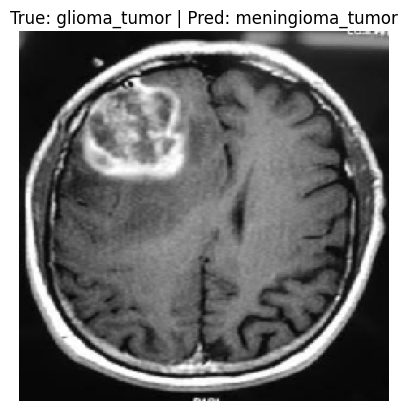

Image 2
True Label:      meningioma_tumor
Predicted Label: meningioma_tumor
------------------------------------


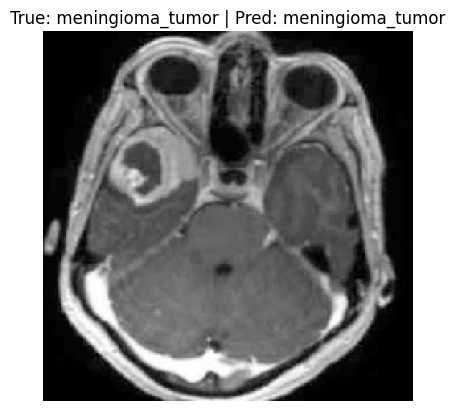

Image 3
True Label:      no_tumor
Predicted Label: no_tumor
------------------------------------


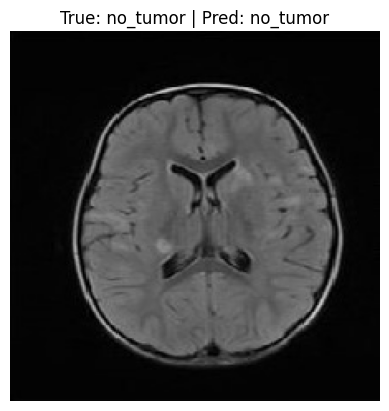

Image 4
True Label:      pituitary_tumor
Predicted Label: pituitary_tumor
------------------------------------


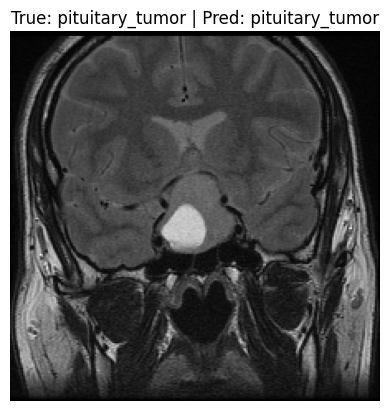

Image 5
True Label:      meningioma_tumor
Predicted Label: meningioma_tumor
------------------------------------


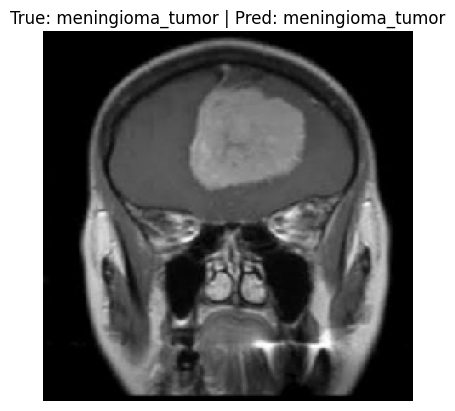

Image 6
True Label:      meningioma_tumor
Predicted Label: meningioma_tumor
------------------------------------


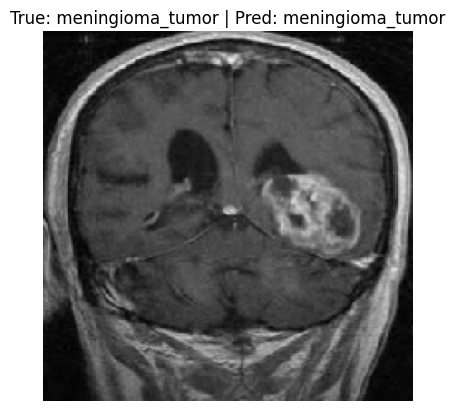


🔥 Test Accuracy: 83.50%
🔥 Test Loss: 1.0104


In [ ]:
# PREDICT ON 6 RANDOM TEST IMAGES

class_names = list(test_set.class_indices.keys())
print("\nClass names:", class_names)

def predict_image(img_path):
    img = load_img(img_path, target_size=(224, 224))
    img_arr = img_to_array(img) / 255.0
    img_arr = np.expand_dims(img_arr, axis=0)
    prediction = model.predict(img_arr, verbose=0)
    predicted_label = class_names[np.argmax(prediction)]
    return img, predicted_label

selected_images = []

# Pick 1 from each class
for class_name in class_names:
    class_folder = os.path.join(test_dir, class_name)
    file = random.choice(os.listdir(class_folder))
    selected_images.append(os.path.join(class_folder, file))

# Pick 2 random images
all_test_paths = []
for class_name in class_names:
    folder = os.path.join(test_dir, class_name)
    for f in os.listdir(folder):
        all_test_paths.append(os.path.join(folder, f))

for _ in range(2):
    selected_images.append(random.choice(all_test_paths))

# Display predictions
print("\n===== PREDICTIONS ON 6 RANDOM TEST IMAGES =====\n")
for idx, img_path in enumerate(selected_images):
    true_label = os.path.basename(os.path.dirname(img_path))
    img, predicted_label = predict_image(img_path)

    print(f"Image {idx+1}")
    print("True Label:     ", true_label)
    print("Predicted Label:", predicted_label)
    print("------------------------------------")

    plt.imshow(img)
    plt.title(f"True: {true_label} | Pred: {predicted_label}")
    plt.axis("off")
    plt.show()

# TEST ACCURACY

loss, accuracy = model.evaluate(test_set, verbose=0)
print(f"\nTest Accuracy: {accuracy * 100:.2f}%")
print(f"Test Loss: {loss:.4f}")